IMT 2200 - Introducción a Ciencia de Datos<br>
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>

---

## Tarea 01 – Cargando y Analizando Datos

- **Fecha de Entrega:** martes 26 de agosto de 2025, a las 23:59.
- 
**Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en l emódulo de Tara 01 habilitado en Canvas.




## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tara.

- Deben hacer sus consultas y comentarios sobre la Tarea a traves del canal de Tareas en eo del curso en Canvas.os.
cteriza.

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

Para los ejercicios a continuación, usted deberá leer, inspeccionar, manipular y graficar conjuntos de datos en distintos formatos, de manera de responder las preguntas de cada parte de la Tarea.

### 1.2 Pregunta de ciencia de datos

Para esta tarea, tendremos como objetivo comprender cómo han cambiado los juegos de mesa en los últimos 40 años. Específicamente queremos saber qué tipos de juegos se han vuelto más comunes hoy en día y qué los caracteriza.

### 1.3 Recomendaciones
- Utiliza las librerías sugeridas en el notebook o justifica brevemente si incorporas otras.
- Revisa que todas las celdas se ejecuten en orden, desde el inicio, sin errores.
- Comenta tu código para explicar qué hace cada sección relevante.
- Asegúrate de que las visualizaciones sean fáciles de interpretar y tengan títulos y etiquetas adecuados.

## 2. Datos

Estaremos utilizando información extraída desde [BoardGameGeek.com](https://boardgamegeek.com/), una plataforma para aficionados de los juegos de mesa, que permite a sus usuarios registrar, calificar e intercambiar sus juegos favoritos. Actualmente, BGG es una de las bases de datos más extensa y diversa de juegos de mesa.

El dataset con el que trabajaremos consiste en un grupo de archivos CSV que contienen información sobre más de 100.000 juegos de mesa almacenados en la plataforma. Este puede descargarse directamente desde el siguiente enlace: https://www.kaggle.com/datasets/mshepherd/board-games Para descargar los datos, haga click en el botón de **Download**, donde podrá descargar los archivos como `.zip`, o bien utilizar la API de Kaggle.

Para el desarrollo de esta tarea, solo utilizaremos los archivos con el prefijo `bgg_`.

**Si utiliza la API de Kaggle para descargar los datos, deje el código utilizado en la siguiente celda:**

In [1]:
# Descarga de datos desde Kaggle

### 2.1 Librerías

Para esta tarea recomendamos al menos usar las librerías indicadas en la siguiente celda del Notebook. Puede agregar otras si lo estima conveniente para responder de mejor forma las preguntas de la Tarea.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast
import os

## 3. Desarrollo

Para cada una de las siguientes preguntas o actividades incluya una o más celdas de código y Markdown con las respuestas o comentarios necesarios para contestar la pregunta o lograr la actividad. Agregue sus celdas a continuación de cada pregunta para que el Notebook quede ordenado.

En el caso de gráficos, figuras o tablas, asegúrese que todas tengan título, etiquetas en los ejes o haya claridad de los contenidos.

### 3.1 DataFrame unificado (1 punto)

Vamos a cargar en un DataFrame los datos de juegos guardados en el documento `bgg_GameItem.csv`. Al inspeccionar nuestros datos, podemos notar que los valores de ciertas comunas vienen "codificados" con ID. Para comenzar, vamos a juntar la información de los distintos archivos descargados.

**a) (0.8 pts)** Genere un DataFrame único con toda la información de cada juego, incluyendo: nombres de artistas y diseñadores involucrados, mecánicas, categorías, tipo, familia y editorial. Guarde este DataFrame en un nuevo archivo CSV.

Prompt a DeepSeek: 

1) Considera este archivo .csv. utilizando pandas quiero generar un DataFrame y filtrar los datos de este csv para que solo me aparezcan las columnas: bgg_id,name,year,designer,artist,mechanic,category,game_type,family,publisher. y con este filtro quiero que me generes un csv nuevo

2) En base a este archivo nuevo quiero editar los valores de cada id entregada en las columnas: 'designer', 'artist', 'mechanic', 'category', 'game_type', 'family', 'publisher' por su respectivo valor el cual es entregado en los archivos: bgg_Category para la columna category, bgg_GameFamily para su columna respectiva, lo mismo para bgg_GameType, bgg_Mechanic, bgg_Publisher y bgg_Person el cual sus id corresponden a las columnas de designer y artist

Y con lo entregado finalmente remplace por los nombres respectivos en la sección de: Cargar todos los diccionarios de referencia

In [4]:


# Leer el archivo CSV
df = pd.read_csv('bgg_GameItem.csv')

# Función para mapear IDs a nombres usando diccionarios de referencia
def mapear_ids_a_nombres(valor, diccionario_referencia):
    if pd.isna(valor):
        return None
    try:
        # Intentar convertir string a lista (para campos con múltiples IDs)
        if isinstance(valor, str) and ',' in valor:
            ids = [int(id_str.strip()) for id_str in valor.split(',')]
            nombres = [diccionario_referencia.get(id, f"Unknown (ID: {id})") for id in ids]
            return ', '.join(nombres)
        else:
            # Para valores individuales
            id_val = int(valor)
            return diccionario_referencia.get(id_val, f"Unknown (ID: {id_val})")
    except (ValueError, TypeError):
        return valor

# Cargar y procesar archivos de referencia
def cargar_diccionario_referencia(archivo, id_col, name_col):
    try:
        df_ref = pd.read_csv(archivo)
        return dict(zip(df_ref[id_col], df_ref[name_col]))
    except FileNotFoundError:
        print(f"Advertencia: Archivo {archivo} no encontrado")
        return {}
    except Exception as e:
        print(f"Error al cargar {archivo}: {e}")
        return {}

# Cargar todos los diccionarios de referencia
categorias_dict = cargar_diccionario_referencia('bgg_Category.csv', 'bgg_id', 'name')
mecanicas_dict = cargar_diccionario_referencia('bgg_Mechanic.csv', 'bgg_id', 'name')
tipos_juego_dict = cargar_diccionario_referencia('bgg_GameType.csv', 'bgg_id', 'name')
familias_dict = cargar_diccionario_referencia('bgg_GameFamily.csv', 'bgg_id', 'name')
editoriales_dict = cargar_diccionario_referencia('bgg_Publisher.csv', 'bgg_id', 'name')
personas_dict = cargar_diccionario_referencia('bgg_Person.csv', 'bgg_id', 'name')

# Aplicar el mapeo a cada columna
print("Procesando columnas...")

# Designer y Artist (usando bgg_Person)
df['designer'] = df['designer'].apply(lambda x: mapear_ids_a_nombres(x, personas_dict))
df['artist'] = df['artist'].apply(lambda x: mapear_ids_a_nombres(x, personas_dict))

# Mechanic
df['mechanic'] = df['mechanic'].apply(lambda x: mapear_ids_a_nombres(x, mecanicas_dict))

# Category
df['category'] = df['category'].apply(lambda x: mapear_ids_a_nombres(x, categorias_dict))

# Game Type
df['game_type'] = df['game_type'].apply(lambda x: mapear_ids_a_nombres(x, tipos_juego_dict))

# Family
df['family'] = df['family'].apply(lambda x: mapear_ids_a_nombres(x, familias_dict))

# Publisher
df['publisher'] = df['publisher'].apply(lambda x: mapear_ids_a_nombres(x, editoriales_dict))

# Guardar el resultado
df.to_csv('bgg_Filtrado.csv', index=False, encoding='utf-8')

print("¡Proceso completado!")
print(f"Archivo 'bgg_Filtrado.csv' creado exitosamente")

Procesando columnas...
¡Proceso completado!
Archivo 'bgg_Filtrado.csv' creado exitosamente


**b) (0.2 pts)** ¿Cuánto espacio en disco ocupa este DataFrame? ¿Cuánto espacio en disco ocupan los documentos CSV separados? ¿A qué se debe esta diferencia? Comente.



In [5]:
tamano_original = os.path.getsize("bgg_GameItem.csv") / (1024 * 1024)  # Byte a MegaByte
nuevo_tamano = os.path.getsize("bgg_Filtrado.csv") / (1024 * 1024)  # Byte a MegaByte

print(f"Tamaño del archivo bgg_GameItem.csv: {tamano_original:.2f} MB")
print(f"El archivo bgg_Filtrado.csv ocupa: {nuevo_tamano:.2f} MB")

Tamaño del archivo bgg_GameItem.csv: 15.33 MB
El archivo bgg_Filtrado.csv ocupa: 29.54 MB


La diferencia se debe a que anteriormente todos los datos sin filtrar solo representaban un valor numérico, los cuales eran sus respectivas ID; en cambio, en el archivo nuevo, pese a estar filtrado y "limpio", incluye el valor real de los datos, sin ninguna clase de codificación.

### 3.2 Juegos publicados anualmente (1.5 puntos)


**a) (0.5 pts)** Limpie los datos para dejar solo aquellos que tienen valores válidos de año de publicación. Luego responda: ¿cuál es el rango de años con el que estamos trabajando? ¿Tienen sentido estos años?


Prompt a DeepSeek: Limpia los datos de bgg_filtrado.csv para dejar solo los años validos.

In [6]:
# Función para limpiar y validar el año
def limpiar_year(valor):
    try:
        # Convertir a numérico y verificar que sea un año válido (positivo y razonable)
        year = pd.to_numeric(valor, errors='coerce')
        if pd.isna(year) or year <= 0 or year > 2025:  # 2025 como límite superior razonable
            return None
        return int(year)
    except (ValueError, TypeError):
        return None

df = pd.read_csv('bgg_Filtrado.csv')

# Limpiar la columna year
print("Limpiando datos de año...")
df['year'] = df['year'].apply(limpiar_year)

# Filtrar solo los registros con año válido
df_limpio = df.dropna(subset=['year']).copy()

print(f"Registros originales: {len(df)}")
print(f"Registros con año válido: {len(df_limpio)}")
print(f"Registros eliminados: {len(df) - len(df_limpio)}")


Limpiando datos de año...
Registros originales: 113904
Registros con año válido: 104195
Registros eliminados: 9709


In [7]:
# Cargar y analizar el rango de años
df = pd.read_csv('bgg_Filtrado.csv')

print("Los 3 juegos más antiguos:")
print(df.nsmallest(3, 'year')[['name', 'year']])

print("\nLos 3 juegos más nuevos:")
print(df.nlargest(3, 'year')[['name', 'year']])

Los 3 juegos más antiguos:
         name    year
2060    Senet -3500.0
3593    Mehen -3000.0
4815  Marbles -3000.0

Los 3 juegos más nuevos:
                  name    year
87637  Template of War  2026.0
99711  Citytrip Junior  2026.0
84728      Farmatropic  2025.0


En base a los juegos mas antiguos y mas nuevos vemos que el rango va desde el año 3500 A.c al 2026 D.c; Lo cual tiene cierto sentido y no, ya que estuve buscando los juegos mas antiguos y coinciden con juegos reales creados en sus respectivos años aproximados, y como estamos en el año 2025 el que un juego haya salido en el 2026 es cuestionable, pero exceptuando lo ultimo mencionado, estos datos tienen sentido.

**b) (0.5 pts)** Seleccione solamente los juegos entre los años 1980 y 2025. Luego grafique la cantidad de juegos publicados por año. ¿Cómo es esta tendencia? Comente.

Prompt: Ahora quiero filtrar del archivo los juegos entre 1980 y 2025 para despues graficar la cantiadad de juego publicados anualmente

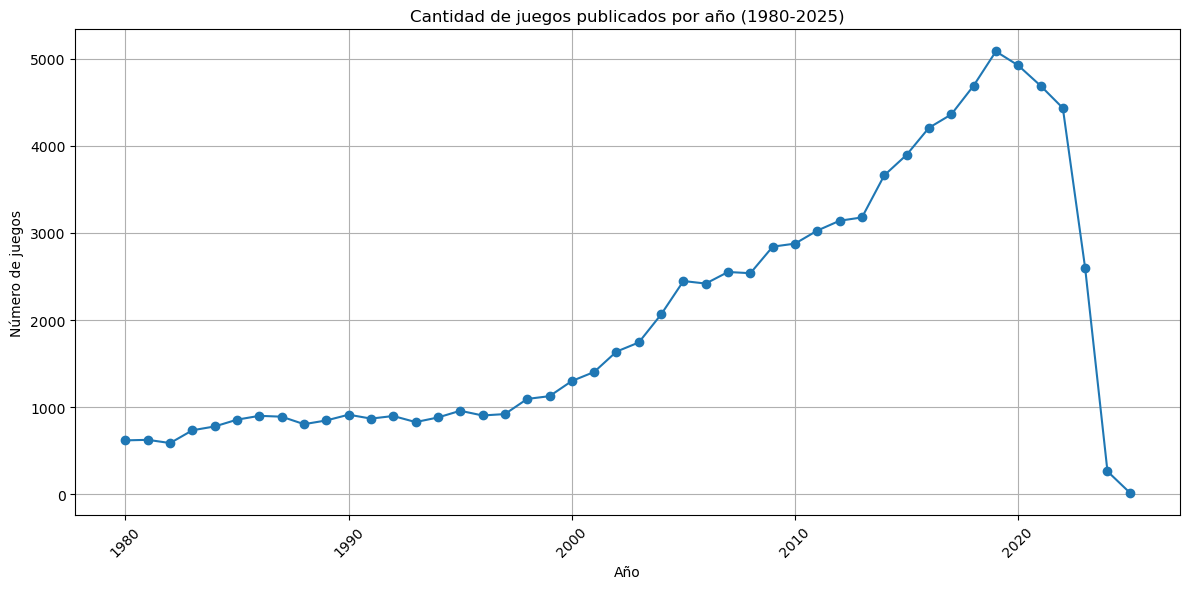


Estadísticas de publicaciones:
Total de juegos en el período: 93019
Año con más publicaciones: 2019.0 (5087 juegos)
Año con menos publicaciones: 2025.0 (16 juegos)


In [8]:
# Cargar el DataFrame
df = pd.read_csv('bgg_Filtrado.csv')

# Filtrar juegos entre 1980 y 2025
games_filtered = df[(df['year'] >= 1980) & (df['year'] <= 2025)]

# Contar juegos por año y ordenar por índice (año)
games_per_year = games_filtered['year'].value_counts().sort_index()

# Crear gráfico
plt.figure(figsize=(12, 6))
plt.plot(games_per_year.index, games_per_year.values, marker='o')
plt.title('Cantidad de juegos publicados por año (1980-2025)')
plt.xlabel('Año')
plt.ylabel('Número de juegos')
plt.grid(True)

# Rotar etiquetas del eje x para mejor legibilidad
plt.xticks(rotation=45)

# Ajustar márgenes
plt.tight_layout()

plt.show()

# Mostrar algunas estadísticas
print("\nEstadísticas de publicaciones:")
print(f"Total de juegos en el período: {len(games_filtered)}")
print(f"Año con más publicaciones: {games_per_year.idxmax()} ({games_per_year.max()} juegos)")
print(f"Año con menos publicaciones: {games_per_year.idxmin()} ({games_per_year.min()} juegos)")

En base al grafico generado se puede apreciar claramente que al principio entre la decada de los 80' y los 2000 la media de juegos  publicados anualmente es similar, principios de los 2000 comienza una tendecia alcista en la publicación de juegos la cual comienza a decaer a poco antes del 2020 y la caida drastica es mas que nada por falta de datos actualizados de juegos en 2025.

**c) (0.5 pts)** ¿Entre qué años hubo un mayor aumento de publicación de juegos de mesa según los registros de BGG?

Edite el rango del codigo anterior solamente para generar un grafico nuevo con todo el rango.

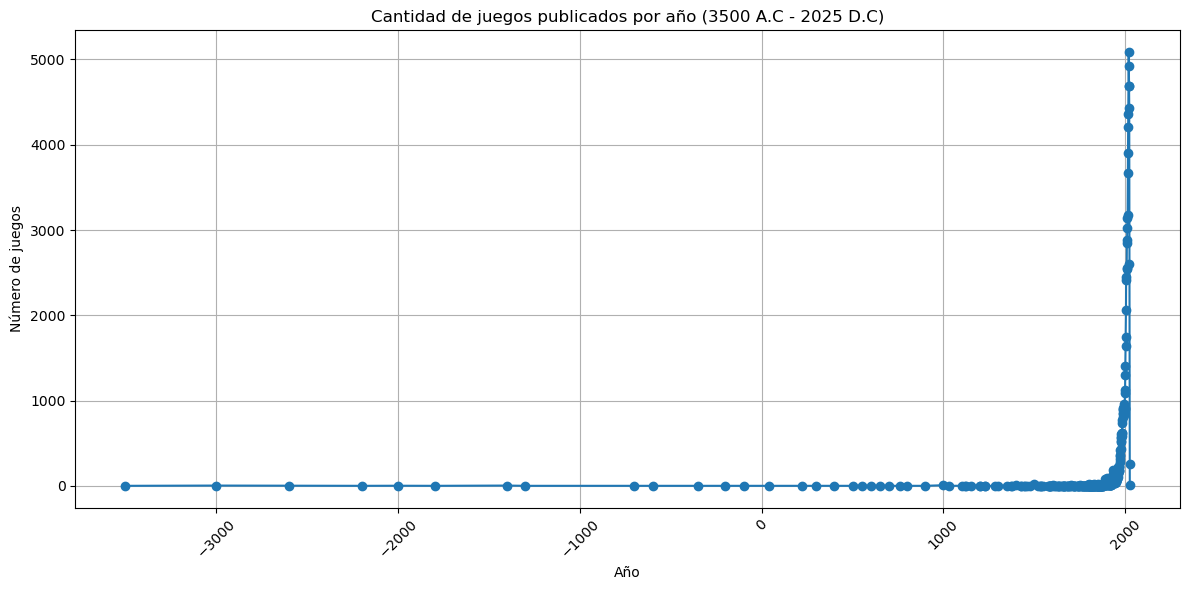

In [9]:
# Filtrar juegos entre -3500 y 2025
games_filtered = df[(df['year'] >= -3500) & (df['year'] <= 2025)]

# Contar juegos por año y ordenar por índice (año)
games_per_year = games_filtered['year'].value_counts().sort_index()

# Crear gráfico
plt.figure(figsize=(12, 6))
plt.plot(games_per_year.index, games_per_year.values, marker='o')
plt.title('Cantidad de juegos publicados por año (3500 A.C - 2025 D.C)')
plt.xlabel('Año')
plt.ylabel('Número de juegos')
plt.grid(True)

# Rotar etiquetas del eje x para mejor legibilidad
plt.xticks(rotation=45)

# Ajustar márgenes
plt.tight_layout()

plt.show()

Como se logra apreciar claramente en el primer y segundo grafico, el rango de años donde se publicaron mas juegos fue entre 2010 y 2020, mostrando un crecimiento notorio comparado a otros años.

### 3.3 Análisis de duración y complejidad (1.5 puntos)

Si bien hay muchas posibles características que podemos explorar para los juegos de mesa, esta vez nos centraremos en el tiempo de juego y la complejidad. En esta sección queremos comprender si se ha modificado notablemente la duración promedio y la percepción de complejidad de los juegos de mesa a través de los años.

**a) (0.3 pts)** Inspecciones y filtre los datos que tengan valores válidos para: tiempo mínimo de juego, tiempo máximo de juego y complejidad. En el caso de que existan "outliers", puede descartarlos, cosiderando un rango razonable para las variables anteriores. Justifique su desición.

Decidí eliminar los outlier porque asi hace menos variable el analisis de los datos.

In [ ]:
# 3.3 a) Inspección y filtrado de datos de tiempo y complejidad

# Cargar el DataFrame limpio
games = pd.read_csv('bgg_Filtrado.csv')

# Filtrar solo juegos entre 1980 y 2025 (como en los análisis anteriores)
games = games[(games['year'] >= 1980) & (games['year'] <= 2025)]

# Convertir columnas relevantes a numéricas (por si acaso)
games['min_time'] = pd.to_numeric(games['min_time'], errors='coerce')
games['max_time'] = pd.to_numeric(games['max_time'], errors='coerce')
games['complexity'] = pd.to_numeric(games['complexity'], errors='coerce')

# Inspeccionar valores
print("Estadísticas de tiempo mínimo:")
print(games['min_time'].describe())
print("\nEstadísticas de tiempo máximo:")
print(games['max_time'].describe())
print("\nEstadísticas de complejidad:")
print(games['complexity'].describe())

# Filtrar datos válidos y eliminar outliers
games_filtered = games[
    (games['min_time'].notna()) &
    (games['max_time'].notna()) &
    (games['complexity'].notna()) &
    (games['min_time'] >= 1) & (games['min_time'] <= 180) &   # 1 a 180 min (3 horas)
    (games['max_time'] >= 1) & (games['max_time'] <= 360) &   # 1 a 360 min (6 horas)
    (games['max_time'] >= games['min_time']) &
    (games['complexity'] >= 1) & (games['complexity'] <= 5)   # escala BGG
].copy()

print(f"\nCantidad de juegos después del filtrado: {len(games_filtered)}")

Estadísticas de tiempo mínimo:
count     79227.000000
mean         49.464993
std         607.949875
min           1.000000
25%          15.000000
50%          30.000000
75%          60.000000
max      157680.000000
Name: min_time, dtype: float64

Estadísticas de tiempo máximo:
count    7.922700e+04
mean     1.490142e+03
std      2.545099e+05
min      1.000000e+00
25%      2.000000e+01
50%      4.000000e+01
75%      6.000000e+01
max      6.307200e+07
Name: max_time, dtype: float64

Estadísticas de complejidad:
count    43387.000000
mean         1.911683
std          0.825894
min          1.000000
25%          1.000000
50%          2.000000
75%          2.435900
max          5.000000
Name: complexity, dtype: float64

Cantidad de juegos después del filtrado: 37952


**b) (0.2 pts)** Veremos ahora si ha cambiado la duración promedio de los juegos de mesa en nuestro rango de años seleccionado. Primero, cree una nueva columna `avg_time` en el dataset con la duración promedio supuesta para cada juego.

In [11]:
# Crear columna de tiempo promedio
games_filtered['avg_time'] = (games_filtered['min_time'] + games_filtered['max_time']) / 2

print("Estadísticas de tiempo promedio:")
print(games_filtered['avg_time'].describe())

Estadísticas de tiempo promedio:
count    37952.000000
mean        49.603736
std         41.784222
min          1.000000
25%         20.000000
50%         32.500000
75%         60.000000
max        270.000000
Name: avg_time, dtype: float64


**c) (0.5 pts)** Grafique la duración promedio de juegos al año entre 1980 y 2025. ¿Existe alguna tendencia? Asegúrese de colocar las unidades correspondientes en sus ejes si es necesario. Comente sus resultados.

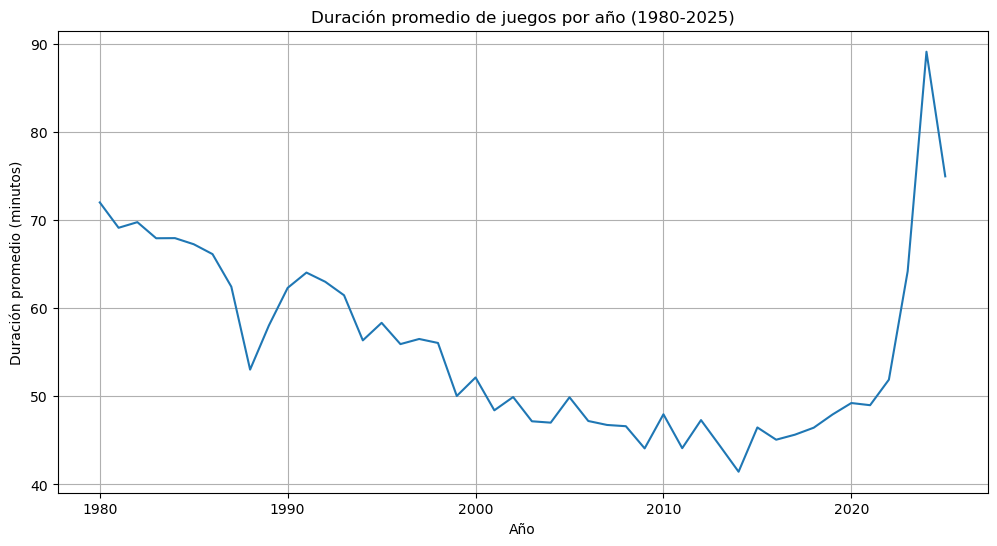

In [12]:
# Calcular duración promedio por año
yearly_avg_time = games_filtered.groupby('year')['avg_time'].mean()

# Filtrar solo años entre 1980 y 2025
yearly_avg_time = yearly_avg_time[(yearly_avg_time.index >= 1980) & (yearly_avg_time.index <= 2025)]

# Graficar tendencia
plt.figure(figsize=(12, 6))
plt.plot(yearly_avg_time.index, yearly_avg_time.values)
plt.title('Duración promedio de juegos por año (1980-2025)')
plt.xlabel('Año')
plt.ylabel('Duración promedio (minutos)')
plt.grid(True)
plt.show()

En principio de los 80, había una duración promedio alta de los juegos. Conforme fueron avanzando los años, se aprecia una tendencia a la baja, lo que significa que hubo juegos de menor duración. El punto más bajo se registró entre 2010 y 2020, y posterior al 2020 comenzó un claro aumento en la duración de los juegos, lo que me hace pensar que se debió a la pandemia.

**d) (0.5 pts)** Nos interesa saber si los juegos de mesa recientes son más complejos que aquellos publicados antes de los 2000. BoardGameGeek permite evaluar la complejidad (o "weight") de un juego en una escala de 1 a 5, siendo 1 un juego "liviano" o fácil de entender, y 5 un juego "pesado" o complejo. Primero, seleccione los juegos que han sido evaluados por al menos 100 usuarios. Luego grafique la complejidad promedio de los juegos según año. Responda: ¿ha cambiado la percepción de complejidad entre juegos entre 1980 y la actualidad?

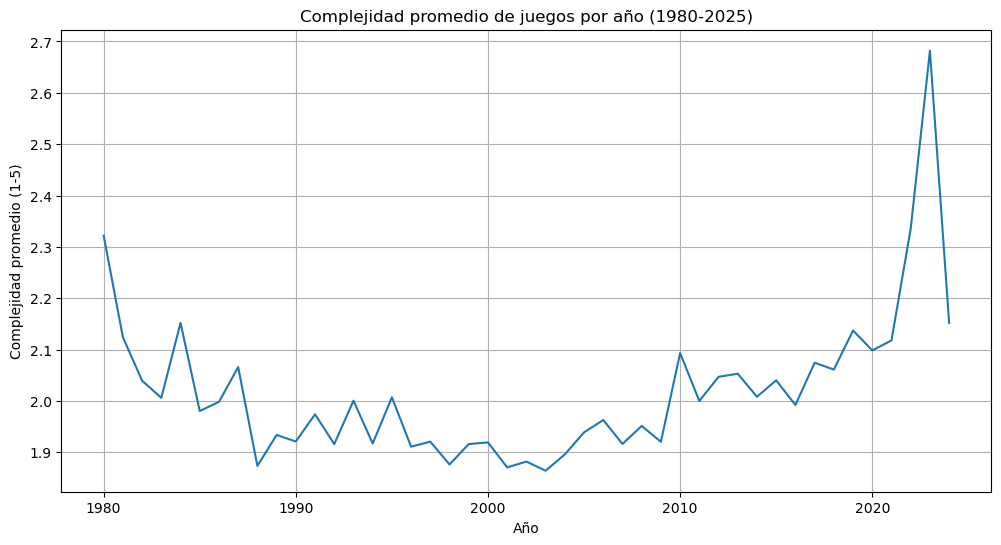


Complejidad promedio antes del 2000: 1.97
Complejidad promedio desde 2000: 2.05


In [13]:
# Filtrar juegos con al menos 100 votos
games_popular = games_filtered[games_filtered['num_votes'] >= 100]

# Calcular complejidad promedio por año
yearly_complexity = games_popular.groupby('year')['complexity'].mean()

# Filtrar años entre 1980 y 2025
yearly_complexity = yearly_complexity[(yearly_complexity.index >= 1980) & 
                                    (yearly_complexity.index <= 2025)]

# Graficar tendencia
plt.figure(figsize=(12, 6))
plt.plot(yearly_complexity.index, yearly_complexity.values)
plt.title('Complejidad promedio de juegos por año (1980-2025)')
plt.xlabel('Año')
plt.ylabel('Complejidad promedio (1-5)')
plt.grid(True)
plt.show()

# Comparar promedios antes y después del 2000
pre_2000 = games_popular[games_popular['year'] < 2000]['complexity'].mean()
post_2000 = games_popular[games_popular['year'] >= 2000]['complexity'].mean()

print(f"\nComplejidad promedio antes del 2000: {pre_2000:.2f}")
print(f"Complejidad promedio desde 2000: {post_2000:.2f}")

ha habido un claro cambio en la dificultad dentro de este rango de años, comenzando con una complejidad promedio de 2.3 puntos(Y un poco más), en los años siguientes fue manteniendo un promedio bastante similar hasta pasado el 2020 en el que se repuntó la dificultad llegando a casi 2.7 puntos.

### 3.4 Análisis de categorías comunes (2 puntos)

Existe una gran diversidad de categorías de juegos de mesa. Ahora nos concentraremos en un grupo específico de ellas, con el fin de analizar cómo a cambiado la cantidad de juegos de estas clases desde 1980 hasta hoy.

**a) (0.7 pts)** ¿Cuáles son las 5 categorías más comunes en los juegos del dataset? Muestre la cantidad de juegos que hay de cada una. Puede graficar estos valores, o bien, entregar un DataFrame con sus valores.

Las 5 categorías más comunes son:
         Categoría  Cantidad de juegos
0        Card Game               25900
1          Wargame               12502
2  Children's Game               11706
3       Party Game                9574
4          Fantasy                8358


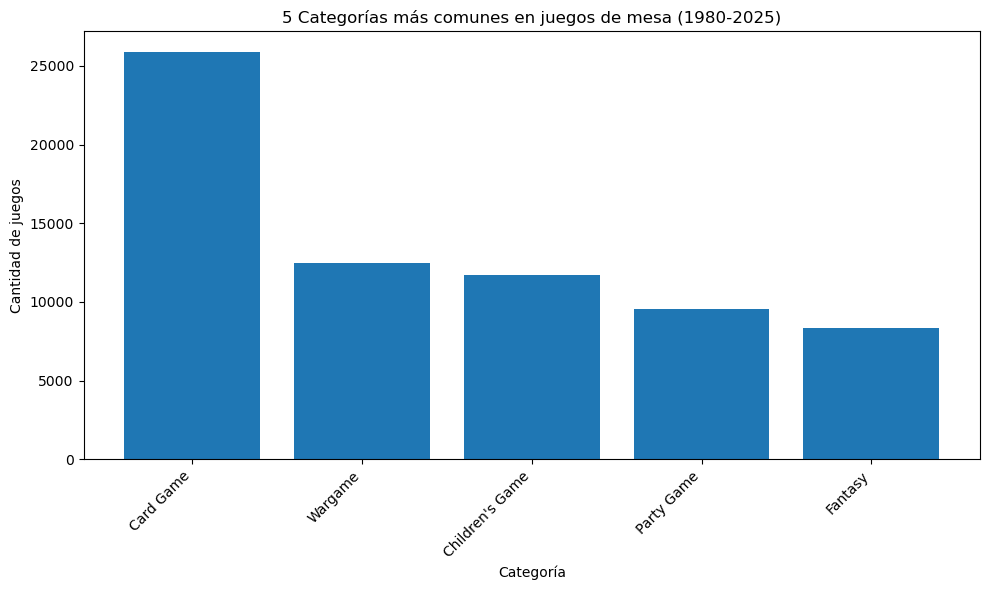

In [14]:
# Filtrar juegos entre 1980 y 2025 para mantener consistencia con análisis anteriores
games = games[(games['year'] >= 1980) & (games['year'] <= 2025)]

# Crear lista de todas las categorías (separando las que están en formato string con comas)
todas_categorias = []
for cats in games['category'].dropna():
    todas_categorias.extend([cat.strip() for cat in str(cats).split(',')])

# Contar frecuencia de cada categoría
frecuencia_categorias = pd.Series(todas_categorias).value_counts()

# Obtener top 5 categorías
top_5_categorias = frecuencia_categorias.head(5)

# Crear DataFrame para mejor visualización
top_categorias = pd.DataFrame({
    'Categoría': top_5_categorias.index,
    'Cantidad de juegos': top_5_categorias.values
})

# Mostrar resultados en tabla
print("Las 5 categorías más comunes son:")
print(top_categorias)

# Crear gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(top_categorias['Categoría'], top_categorias['Cantidad de juegos'])
plt.title('5 Categorías más comunes en juegos de mesa (1980-2025)')
plt.xlabel('Categoría')
plt.ylabel('Cantidad de juegos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**b) (0.3 pts)** Para cada una de estas 5 categorías, cree un DataFrame que contenga la cantidad de juegos en el dataset según año. Luego junte estos DataFrames en uno solo con los atributos de "Año", "Categoría" y "Cantidad".

In [15]:
# Crear DataFrame para cada categoría
dfs = []
for cat in top_5_categorias.index:  # Usando el resultado del análisis anterior
    # Filtrar juegos que contengan la categoría
    cat_games = games[games['category'].str.contains(str(cat), na=False)]
    
    # Contar juegos por año
    yearly_count = cat_games['year'].value_counts().reset_index()
    yearly_count.columns = ['Año', 'Cantidad']
    yearly_count['Categoría'] = cat
    
    dfs.append(yearly_count)

# Unir todos los DataFrames
categories_by_year = pd.concat(dfs, ignore_index=True)

# Ordenar por año y categoría
categories_by_year = categories_by_year.sort_values(['Año', 'Categoría'])

# Mostrar las primeras filas del DataFrame unificado
print("Muestra del DataFrame unificado:")
print(categories_by_year.head(15))

# Mostrar información básica del DataFrame
print("\nInformación del DataFrame:")
print(f"Total de filas: {len(categories_by_year)}")
print(f"Rango de años: {categories_by_year['Año'].min()} - {categories_by_year['Año'].max()}")

Muestra del DataFrame unificado:
        Año  Cantidad        Categoría
44   1980.0        43        Card Game
134  1980.0        75  Children's Game
224  1980.0        33          Fantasy
180  1980.0         8       Party Game
72   1980.0       170          Wargame
43   1981.0        52        Card Game
133  1981.0        76  Children's Game
218  1981.0        40          Fantasy
179  1981.0        11       Party Game
70   1981.0       181          Wargame
41   1982.0        58        Card Game
135  1982.0        60  Children's Game
225  1982.0        30          Fantasy
178  1982.0        11       Party Game
80   1982.0       140          Wargame

Información del DataFrame:
Total de filas: 228
Rango de años: 1980.0 - 2025.0


**c) (1 pto)** Grafique, en un solo gráfico y con distintos colores, la cantidad de juegos por año según categoría. Preocúpese de ponerle etiquetas al gráfico para identificar cada categoría y una leyenda donde se muestre cada una. Comente: ¿ha habido un cambio entre los juegos más comunes en los años 80 y hoy?


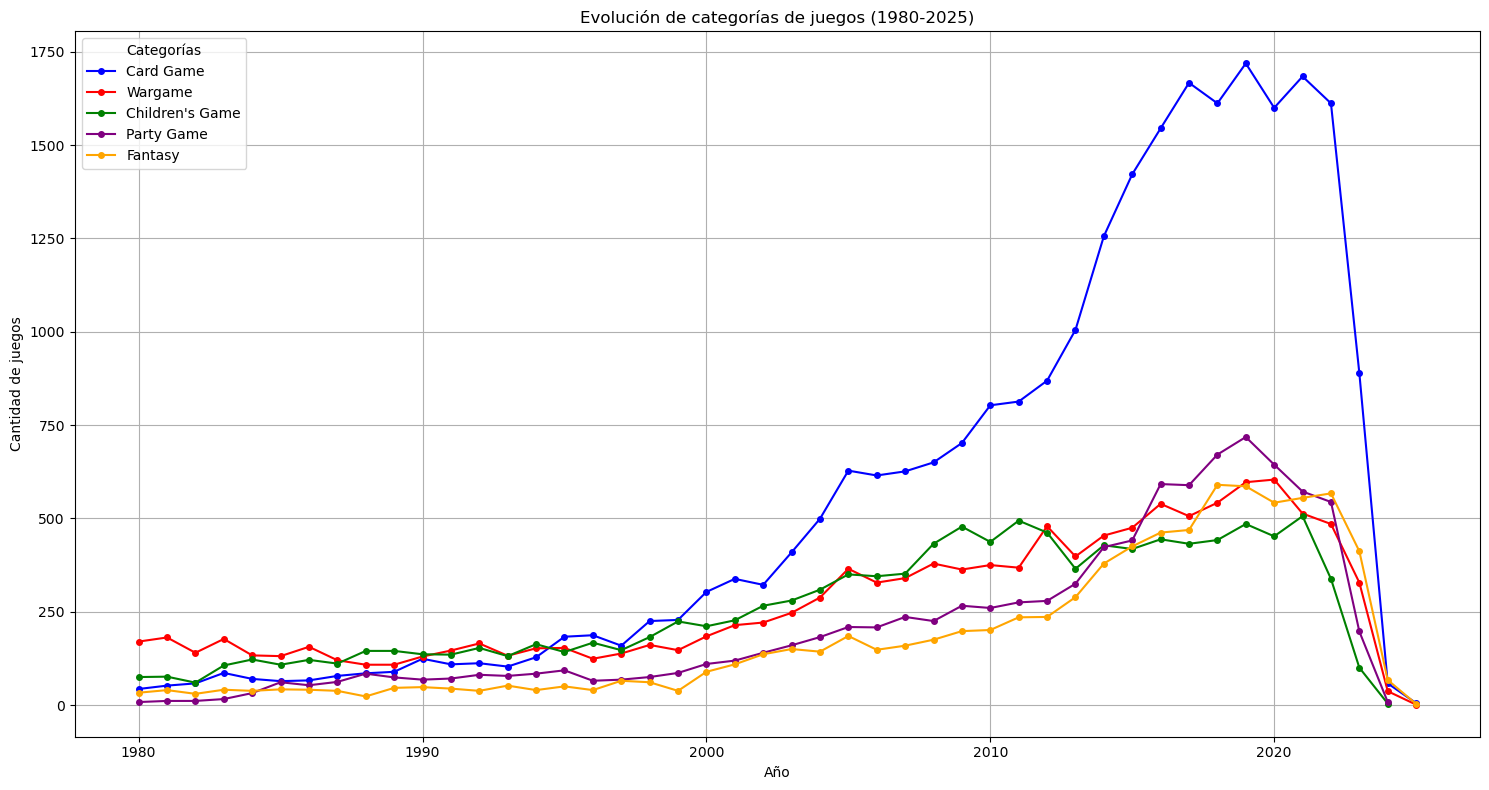

In [16]:
# Filtrar años entre 1980 y 2025
categories_by_year_filtered = categories_by_year[
    (categories_by_year['Año'] >= 1980) & 
    (categories_by_year['Año'] <= 2025)
]

# Crear gráfico de líneas para cada categoría
plt.figure(figsize=(15, 8))

# Usar diferentes colores para cada categoría
colors = ['blue', 'red', 'green', 'purple', 'orange']

for cat, color in zip(top_5_categorias.index, colors):
    cat_data = categories_by_year_filtered[categories_by_year_filtered['Categoría'] == cat]
    plt.plot(cat_data['Año'], cat_data['Cantidad'], label=cat, 
             color=color, marker='o', markersize=4)

plt.title('Evolución de categorías de juegos (1980-2025)')
plt.xlabel('Año')
plt.ylabel('Cantidad de juegos')
plt.legend(title='Categorías', loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

Analizando las categorías entre 1980 y 2025, se notan varios cambios significativos:

I) Entre los 80´ y 90´, la distribución de datos entre categorías era relativamente uniforme y con números bajos.

II) Comenzando los 2000, se logra ver un claro crecimiento en todas las categorías

III) El mayor cambio ocurre entre 2010-2020, donde hay un aumento drastico en todas las categorias.

VI) Los juegos de cartas han ido creciendo claramente en cantidad conforme van pasando los años.

### 3.5 Análisis Crítico (Bono +0.5 puntos)

¿Qué limitaciones o problemas encontraste en los datos?

In [21]:
# Analizar problemas en los datos
print("Limitaciones y problemas encontrados en los datos:")

# Verificar valores nulos
print("\n1. Valores nulos por columna:")
print(games.isnull().sum())

# Verificar consistencia en años
print("\n2. Rango de años:")
print(f"Mínimo: {games['year'].min()}")
print(f"Máximo: {games['year'].max()}")

# Verificar consistencia en tiempos
print("\n3. Inconsistencias en tiempos de juego:")
inconsistent_times = games[games['max_time'] < games['min_time']].shape[0]
print(f"Juegos con tiempo máximo menor al mínimo: {inconsistent_times}")

# Verificar valores atípicos en complejidad
print("\n4. Valores atípicos en complejidad:")
print(games['complexity'].describe())

Limitaciones y problemas encontrados en los datos:

1. Valores nulos por columna:
bgg_id                     0
name                       0
year                       0
game_type              71061
designer               12503
artist                 49133
publisher                 39
min_players              828
max_players             3147
min_players_rec          828
max_players_rec         3147
min_players_best         828
max_players_best        3147
min_age                14493
min_age_rec            91959
min_time               13792
max_time               13792
category                1649
mechanic               12317
cooperative            87032
compilation            92186
compilation_of         92186
family                 27072
implementation         87510
integration            89030
rank                   70068
num_votes              18588
avg_rating             18588
stddev_rating          32335
bayes_rating           69643
complexity             49632
language_dependency